# Workshop 1 (Machine Learning)

## Análisis Exploratorio de Datos (EDA) con NumPy y Pandas

### Objetivo

Aplicar el ciclo completo de exploración de datos: reconocimiento inicial, limpieza (cleaning), análisis descriptivo y visualización, usando un dataset real de Kaggle.

## Fase 1 (Reconocimiento Inicial del Dataset)

### 1. ¿De qué trata el Dataset?

El dataset contiene información demográfica y académica de 1.000 estudiantes. Incluye variables categóricas como género, grupo de raza/etnia, nivel educativo de los padres, tipo de almuerzo y realización de un curso de preparación, además de las calificaciones obtenidas en matemáticas, lectura y escritura. El objetivo del análisis es explorar cómo se distribuye el desempeño académico y posteriormente analizar posibles relaciones entre estas características y las calificaciones.

### 2. Primeras y Últimas filas del Dataset

Utilizaremos los métodos propios de la libreria Pandas .head() y .tail() para mostrar las primeras y las últimas cinco filas del dataset.

#### Importación de Librerias:

In [2]:
import numpy as np
import pandas as pd

#### Lectura del Dataset:

In [3]:
students_data = pd.read_csv("data/StudentsPerformance.csv")

#### Primeras 5 filas:

In [4]:
students_data.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


#### Últimas 5 filas:

In [5]:
students_data.tail()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77
999,female,group D,some college,free/reduced,none,77,86,86


### 3. Filas y Columnas del Dataset:

In [6]:
students_data.shape

(1000, 8)

#### ¿Qué representa cada una?

Columna 0 (gender): Esta columna es el género del estudiante, es string u object porque se clasifica en "male" y "female".

Colunma 1 (race/ethnicity): Esta columna nos brinda información acerca de la raza y etnia a la que pertenece dicho estudiante. Es de tipo string u object ya que se clasifica en "group A", "group B", "group C", "group D", "group E".

Columna 2 (parental level of education): Esta columna indica el nivel de educación de los padres de acuerdo a cada niño.

Columna 3 (lunch): Indica como es el almuerzo de los niños, en pocas palabras, si comen o no bien.

Columna 4 (test preparation course): Indica si efectivamente realizaron un test de preparacion para presentar el examen del cual tenemos las calificaciones en este mismo dataset.

Columna 5 (math score): Indica cuanto saco el niño en Matematicas.

Columna 6 (reading score): Indica cuanto saco el niño en Lectura.

Columna 7 (writing score): Indica cuanto saco el niño en Escritura.

### 4. ¿Cómo son las columnas de nuestro Dataset?

In [7]:
students_data.dtypes

gender                         object
race/ethnicity                 object
parental level of education    object
lunch                          object
test preparation course        object
math score                      int64
reading score                   int64
writing score                   int64
dtype: object

In [8]:
students_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


A partir de .info() y .dtypes() podemos identificar 5 variables categóricas (gender, race/ethnicity, parental level of education, lunch y test preparation course) y 3 variables numéricas (math score, reading score y writing score). El dataset no contiene variables de tipo fecha. Además, todas las columnas tienen 1.000 registros no nulos.


### 5. Datos Estadisticos


In [9]:
students_data.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


#### Interpretación de los datos estadisticos

La calificación media en matemáticas es aproximadamente 66.09 puntos, mientras que lectura y escritura presentan medias ligeramente superiores, de 69.17 y 68.05 respectivamente. Esto sugiere que, dentro de este conjunto de datos, el desempeño promedio es ligeramente mayor en lectura que en matemáticas.

Las desviaciones estándar se encuentran alrededor de 15 puntos en las tres asignaturas. Esto indica que las calificaciones presentan una dispersión similar en matemáticas, lectura y escritura. En otras palabras, en cada materia las calificaciones suelen alejarse aproximadamente 14-15 puntos de su respectiva media.

El valor mínimo de matemáticas es 0, mientras que los mínimos de lectura y escritura son 17 y 10 respectivamente. Esto muestra que los resultados más extremos por la parte inferior se presentan en matemáticas. Sin embargo, para determinar en qué materia existe un mejor desempeño general es más apropiado observar las medias y medianas, donde lectura presenta el valor promedio más alto.

### 6. Calculo manual de la media, mediana y desviacion estandar

In [9]:
math_score_array = students_data["math score"].to_numpy()
reading_score_array = students_data["reading score"].to_numpy()
writing_score_array = students_data["writing score"].to_numpy()

print("Datos Estadisticos con NumPy de la columna 'Math Score':")
print("Media: ", np.mean(math_score_array))
print("Mediana: ", np.median(math_score_array))
print("Desviación Estándar: ", np.std(math_score_array), "\n")

print("Datos Estadisticos con NumPy de la columna 'Reading Score':")
print("Media: ", np.mean(reading_score_array))
print("Mediana: ", np.median(reading_score_array))
print("Desviación Estándar: ", np.std(reading_score_array), "\n")

print("Datos Estadisticos con NumPy de la columna 'Writing Score':")
print("Media: ", np.mean(writing_score_array))
print("Mediana: ", np.median(writing_score_array))
print("Desviación Estándar: ", np.std(writing_score_array), "\n")


Datos Estadisticos con NumPy de la columna 'Math Score':
Media:  66.089
Mediana:  66.0
Desviación Estándar:  15.155496659628149 

Datos Estadisticos con NumPy de la columna 'Reading Score':
Media:  69.169
Mediana:  70.0
Desviación Estándar:  14.592890015346516 

Datos Estadisticos con NumPy de la columna 'Writing Score':
Media:  68.054
Mediana:  69.0
Desviación Estándar:  15.188057281956768 



#### Nota:

Se observa una ligera diferencia entre la desviación estándar calculada por describe() y np.std(). Esto ocurre porque Pandas utiliza por defecto la desviación estándar muestral (ddof=1), mientras que NumPy utiliza la poblacional (ddof=0).

## Fase 2 (Limpieza de Datos/Data Cleaning)

### 7. Valores Nulos


In [10]:
students_data.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [10]:
null_values = students_data.isnull().sum()

null_percentage = (
    students_data.isnull().sum()
    / len(students_data)
) * 100

null_report = pd.DataFrame({
    "Null Values": null_values,
    "Percentage": null_percentage
})

null_report

,Null Values,Percentage
gender,0,0.0
race/ethnicity,0,0.0
parental level of education,0,0.0
lunch,0,0.0
test preparation course,0,0.0
math score,0,0.0
reading score,0,0.0
writing score,0,0.0


### 8. Imputación de Valores Nulos

Al buscar valores nulos dentro de nuestro dataset, nos damos cuenta que realmente no hay, nuestro conjunto de datos esta totalmente lleno, por lo que no debemos de implementar ninguna técnica de llenado o imputación de datos.

### 9. Valores Duplicados

In [11]:
students_data.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
995    False
996    False
997    False
998    False
999    False
Length: 1000, dtype: bool

In [12]:
students_data.duplicated().sum()

np.int64(0)

In [13]:
students_data.drop_duplicates()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


#### Nota:

Al buscar valores duplicados dentro de nuestro dataset, nos damos cuenta que realmente no hay, nuestro conjunto de datos esta totalmente normal, cada fila es unica, por lo que no debemos de implementar ninguna técnica de eliminación de filas, dado que no es necesario. Cuando tratamos de eliminar filas duplicadas, nos damos cuenta de que en realidad no se elimina ninguna, ya que no hay diplicaciones.

### 10. Inconsistencias de Formato

In [14]:
students_data.nunique()

gender                          2
race/ethnicity                  5
parental level of education     6
lunch                           2
test preparation course         2
math score                     81
reading score                  72
writing score                  77
dtype: int64

In [15]:
students_data["gender"].unique()

<StringArray>
['female', 'male']
Length: 2, dtype: str

In [16]:
students_data["race/ethnicity"].unique()

<StringArray>
['group B', 'group C', 'group A', 'group D', 'group E']
Length: 5, dtype: str

In [17]:
students_data["parental level of education"].unique()

<StringArray>
[ 'bachelor's degree',       'some college',    'master's degree',
 'associate's degree',        'high school',   'some high school']
Length: 6, dtype: str

In [18]:
students_data["lunch"].unique()

<StringArray>
['standard', 'free/reduced']
Length: 2, dtype: str

In [19]:
students_data["test preparation course"].unique()

<StringArray>
['none', 'completed']
Length: 2, dtype: str

#### Nota

En ninguna columna que contiene datos categoricos se presentan inconsistencias de formato, los datos que allí se hayan son todos consistentes y no hay ninguno que sea diferente a las convenciones usadas.

### 11. Valores Atípicos

#### Con Math Score:

In [14]:
math_score_q1 = students_data["math score"].quantile(0.25)
math_score_q2 = students_data["math score"].quantile(0.50)
math_score_q3 = students_data["math score"].quantile(0.75)

math_score_iqr = math_score_q3 - math_score_q1

lower_bound_outlier_math_score = math_score_q1 - 1.5 * math_score_iqr
upper_bound_outlier_math_score = math_score_q3 + 1.5 * math_score_iqr

math_score_outliers = students_data[(students_data["math score"] < lower_bound_outlier_math_score) |
                                    (students_data["math score"] > upper_bound_outlier_math_score)]

print("Cuartiles de Math Score:\n",
      "Q1 (25%): ", math_score_q1, "\n",
      "Q2 (50%): ", math_score_q2, "\n",
      "Q3 (75%): ", math_score_q3, "\n")

print("Rango Intercuartilico: \n",
      "IQR: ", math_score_iqr, "\n")

print("Límites para Outliers: \n",
      "Inferior: ", lower_bound_outlier_math_score, "\n",
      "Superior: ", upper_bound_outlier_math_score, "\n")

print("Outliers en Math Score: ", math_score_outliers, "\n")

Cuartiles de Math Score:
 Q1 (25%):  57.0 
 Q2 (50%):  66.0 
 Q3 (75%):  77.0 

Rango Intercuartilico: 
 IQR:  20.0 

Límites para Outliers: 
 Inferior:  27.0 
 Superior:  107.0 

Outliers en Math Score:       gender race/ethnicity parental level of education         lunch  \
17   female        group B            some high school  free/reduced   
59   female        group C            some high school  free/reduced   
145  female        group C                some college  free/reduced   
338  female        group B            some high school  free/reduced   
466  female        group D          associate's degree  free/reduced   
787  female        group B                some college      standard   
842  female        group B                 high school  free/reduced   
980  female        group B                 high school  free/reduced   

    test preparation course  math score  reading score  writing score  
17                     none          18             32             28  
59

#### Con Reading Score:

In [15]:
reading_score_q1 = students_data["reading score"].quantile(0.25)
reading_score_q2 = students_data["reading score"].quantile(0.50)
reading_score_q3 = students_data["reading score"].quantile(0.75)

reading_score_iqr = reading_score_q3 - reading_score_q1

lower_bound_outlier_reading_score = reading_score_q1 - 1.5 * reading_score_iqr
upper_bound_outlier_reading_score = reading_score_q3 + 1.5 * reading_score_iqr

reading_score_outliers = students_data[(students_data["reading score"] < lower_bound_outlier_reading_score) |
                                       (students_data["reading score"] > upper_bound_outlier_reading_score)]

print("Cuartiles de Reading Score:\n",
      "Q1 (25%): ", reading_score_q1, "\n",
      "Q2 (50%): ", reading_score_q2, "\n",
      "Q3 (75%): ", reading_score_q3, "\n",
      "IQR: ", reading_score_iqr, "\n")

print("Rango Intercuartilico: \n",
      "IQR: ", reading_score_iqr, "\n")

print("Límites para Outliers: \n",
      "Inferior: ", lower_bound_outlier_reading_score, "\n",
      "Superior: ", upper_bound_outlier_reading_score, "\n")

print("Outliers en Reading Score: ", reading_score_outliers, "\n")


Cuartiles de Reading Score:
 Q1 (25%):  59.0 
 Q2 (50%):  70.0 
 Q3 (75%):  79.0 
 IQR:  20.0 

Rango Intercuartilico: 
 IQR:  20.0 

Límites para Outliers: 
 Inferior:  29.0 
 Superior:  109.0 

Outliers en Reading Score:       gender race/ethnicity parental level of education         lunch  \
59   female        group C            some high school  free/reduced   
76     male        group E            some high school      standard   
211    male        group C                some college  free/reduced   
327    male        group A                some college  free/reduced   
596    male        group B                 high school  free/reduced   
980  female        group B                 high school  free/reduced   

    test preparation course  math score  reading score  writing score  
59                     none           0             17             10  
76                     none          30             26             22  
211                    none          35             28 

#### Con Writing Score:

In [16]:
writing_score_q1 = students_data["writing score"].quantile(0.25)
writing_score_q2 = students_data["writing score"].quantile(0.50)
writing_score_q3 = students_data["writing score"].quantile(0.75)

writing_score_iqr = writing_score_q3 - writing_score_q1

lower_bound_outlier_writing_score = writing_score_q1 - 1.5 * writing_score_iqr
upper_bound_outlier_writing_score = writing_score_q3 + 1.5 * writing_score_iqr

writing_score_outliers = students_data[(students_data["writing score"] < lower_bound_outlier_writing_score) |
                                       (students_data["writing score"] > upper_bound_outlier_writing_score)]

print("Cuartiles de Writing Score:\n",
      "Q1 (25%): ", writing_score_q1, "\n",
      "Q2 (50%): ", writing_score_q2, "\n",
      "Q3 (75%): ", writing_score_q3, "\n",
      "IQR: ", writing_score_iqr, "\n")

print("Rango Intercuartilico: \n",
      "IQR: ", writing_score_iqr, "\n")

print("Límites para Outliers: \n",
      "Inferior: ", lower_bound_outlier_writing_score, "\n",
      "Superior: ", upper_bound_outlier_writing_score, "\n")

print("Outliers en Writing Score: ", writing_score_outliers, "\n")

Cuartiles de Writing Score:
 Q1 (25%):  57.75 
 Q2 (50%):  69.0 
 Q3 (75%):  79.0 
 IQR:  21.25 

Rango Intercuartilico: 
 IQR:  21.25 

Límites para Outliers: 
 Inferior:  25.875 
 Superior:  110.875 

Outliers en Writing Score:       gender race/ethnicity parental level of education         lunch  \
59   female        group C            some high school  free/reduced   
76     male        group E            some high school      standard   
327    male        group A                some college  free/reduced   
596    male        group B                 high school  free/reduced   
980  female        group B                 high school  free/reduced   

    test preparation course  math score  reading score  writing score  
59                     none           0             17             10  
76                     none          30             26             22  
327                    none          28             23             19  
596                    none          30         

#### Nota

Como podemos ver, en cada una de las columnas que contienen datos numericos (math score, reading score y writing score) se presentan valores atípicos, o en otras palabras, outliers. Para hallarlos lo primero que hicimos fue encontrar los cuartiles (Q1, Q2, y Q3), acto seguido encontramos el rango intercuartilico (IQR) y los limites, tanto el inferior como el superior, con la fórmula usada en clase. Asi es como con estos valores, buscamos dentro de nuestro dataset aquellos valores que son poco comunes con respecto al resto de los datos.

El análisis mediante IQR identificó 8 valores atípicos en matemáticas, 6 en lectura y 5 en escritura. En los tres casos los outliers corresponden exclusivamente a calificaciones excepcionalmente bajas. No se presentan outliers superiores debido a que los límites superiores calculados mediante IQR son mayores que 100, que corresponde al máximo posible de las calificaciones.

Aunque estos valores son estadísticamente atípicos, no se eliminarán del dataset, ya que se encuentran dentro del rango válido de calificaciones (0 a 100) y podrían representar estudiantes con un desempeño académico genuinamente bajo. Eliminarlos podría eliminar información relevante del fenómeno estudiado.

## Fase 3 (Exploración y Análisis Descriptivo)

### 12. Categorías en columnas categóricas

Vamos a identificar las categorías presentes en dos columnas categóricas relevantes: "parental level of education" y "test preparation course", y cuántos registros tiene cada categoría.

In [23]:
students_data["parental level of education"].value_counts()

parental level of education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64

In [24]:
students_data["test preparation course"].value_counts()

test preparation course
none         642
completed    358
Name: count, dtype: int64

La mayoría de los estudiantes tiene padres con educación de 'some college' o 'associate's degree' (226 y 222 respectivamente), mientras que muy pocos tienen padres con maestría (59). En cuanto a la preparación, el 64.2% de los estudiantes (642 de 1000) no completó el curso de preparación, lo que sugiere una oportunidad de mejora si se buscara aumentar el desempeño general.

### 13. Diccionario con métrica agregada por categoría (subconjunto filtrado)

Vamos a construir un diccionario donde la clave sea cada grupo de "race/ethnicity" y el valor sea el promedio de "math score", pero calculado únicamente para los estudiantes que SÍ completaron el curso de preparación (test preparation course == "completed"). Esto simula el ejercicio visto en clase donde se filtra primero por una condición y luego se agrega la métrica.

In [25]:
completado = students_data[students_data["test preparation course"] == "completed"]

promedio_math_por_grupo = {}

for grupo in completado["race/ethnicity"].unique():
    subconjunto = completado[completado["race/ethnicity"] == grupo]
    promedio_math_por_grupo[grupo] = subconjunto["math score"].mean()

promedio_math_por_grupo

{'group C': np.float64(67.4957264957265),
 'group B': np.float64(67.19117647058823),
 'group D': np.float64(69.79268292682927),
 'group A': np.float64(68.25806451612904),
 'group E': np.float64(77.43333333333334)}

Incluso filtrando solo a quienes completaron el curso de preparación, el grupo E mantiene el promedio más alto en matemáticas (77.4), muy por encima del grupo B (67.2), que es el más bajo. Esto indica que el efecto del curso de preparación no elimina las diferencias entre grupos étnicos, por lo que probablemente hay otros factores (socioeconómicos, de acceso a recursos) influyendo en el desempeño.

### 14. Preguntas de negocio con groupby()

Pregunta 1: ¿Cuál es el promedio de puntaje en matemáticas según el nivel de educación de los padres?

Pregunta 2: ¿Cuál es el promedio de puntaje en las tres materias (matemáticas, lectura y escritura) según si el estudiante completó o no el curso de preparación?

In [26]:
students_data.groupby("parental level of education")["math score"].mean().sort_values(ascending=False)

parental level of education
master's degree       69.745763
bachelor's degree     69.389831
associate's degree    67.882883
some college          67.128319
some high school      63.497207
high school           62.137755
Name: math score, dtype: float64

In [27]:
students_data.groupby("test preparation course")[["math score", "reading score", "writing score"]].mean()

,math score,reading score,writing score
test preparation course,,,
completed,69.695531,73.893855,74.418994
none,64.077882,66.534268,64.504673


Se confirma una relación entre el nivel educativo de los padres y el desempeño en matemáticas: el promedio baja de forma casi escalonada desde 'master's degree' (69.7) hasta 'high school' (62.1), una diferencia de más de 7 puntos. Respecto al curso de preparación, los estudiantes que lo completaron superan en promedio a los que no lo hicieron en las tres materias, con la mayor diferencia en 'writing score' (74.4 vs 64.5, casi 10 puntos), lo que sugiere que el curso tiene mayor impacto en habilidades de escritura que en matemáticas

### 15. Ordenar el Dataset (Top 5 y Bottom 5 según puntaje total)

Vamos a crear una columna adicional "total_score" que sume las tres materias, y luego ordenar el dataset para identificar los 5 estudiantes con mejor desempeño general y los 5 con peor desempeño.

In [28]:
students_data["total_score"] = students_data["math score"] + students_data["reading score"] + students_data["writing score"]

top_5 = students_data.sort_values(by="total_score", ascending=False).head(5)
top_5

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total_score
962,female,group E,associate's degree,standard,none,100,100,100,300
458,female,group E,bachelor's degree,standard,none,100,100,100,300
916,male,group E,bachelor's degree,standard,completed,100,100,100,300
114,female,group E,bachelor's degree,standard,completed,99,100,100,299
179,female,group D,some high school,standard,completed,97,100,100,297


In [29]:
bottom_5 = students_data.sort_values(by="total_score", ascending=True).head(5)
bottom_5

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total_score
59,female,group C,some high school,free/reduced,none,0,17,10,27
980,female,group B,high school,free/reduced,none,8,24,23,55
596,male,group B,high school,free/reduced,none,30,24,15,69
327,male,group A,some college,free/reduced,none,28,23,19,70
76,male,group E,some high school,standard,none,30,26,22,78


Los 5 estudiantes con mayor puntaje total (297-300) comparten lunch tipo 'standard' y en su mayoría pertenecen al grupo E, mientras que los 5 con menor puntaje (27-78) tienen lunch 'free/reduced' y ninguno completó el curso de preparación. Esto sugiere que el tipo de almuerzo (posible proxy de nivel socioeconómico) y la preparación previa son factores fuertemente asociados al desempeño extremo, tanto alto como bajo.

## Fase 4 (Visualización - EDA gráfico)

Para cada gráfica se incluye el código, la imagen generada y un párrafo de interpretación (qué se observa, qué sugiere sobre los datos) junto con una recomendación desde el rol de una persona encargada de la toma de decisiones.

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (8, 5)


### 16. Gráfico de barras: distribución de "parental level of education"

Elegimos esta variable categórica porque representa el nivel educativo de los padres, un factor que ya identificamos como relevante para el desempeño académico en la Fase 3.

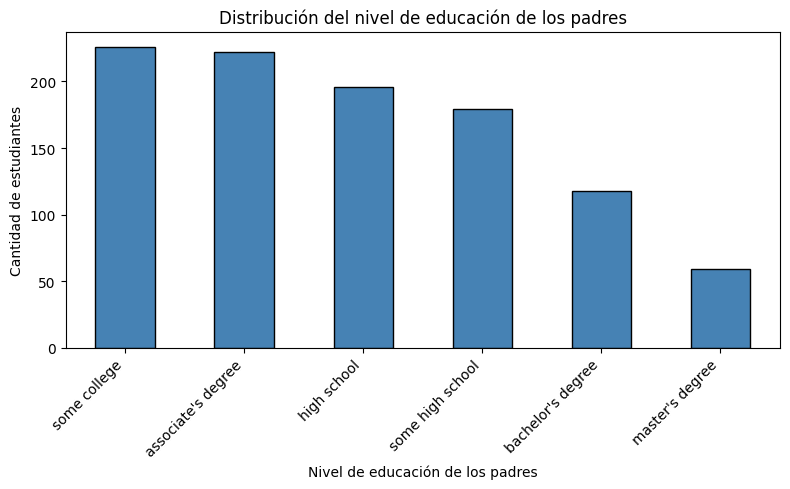

In [31]:
orden = students_data["parental level of education"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(8,5))
orden.plot(kind="bar", color="steelblue", edgecolor="black")
plt.title("Distribución del nivel de educación de los padres")
plt.xlabel("Nivel de educación de los padres")
plt.ylabel("Cantidad de estudiantes")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


**Interpretación:** La categoría más frecuente es "some college" (226 estudiantes), seguida muy de cerca por "associate's degree" (222), mientras que "master's degree" es la menos común (59 estudiantes, apenas el 5.9% del total). Esto confirma que la mayoría de los padres tiene estudios de nivel medio-superior (universidad incompleta o técnico), y muy pocos alcanzan posgrado.

**Recomendación:** Si se busca diseñar programas de apoyo académico focalizados en el hogar (por ejemplo, talleres para padres), conviene priorizar estrategias que no dependan de que el padre/madre tenga estudios avanzados, ya que la mayoría no los tiene.

### 17. Gráfico de pie: proporción de "test preparation course"

Esta variable categórica binaria (completado / no completado) es clave porque en la Fase 3 vimos que se asocia con diferencias de hasta 10 puntos en los puntajes.

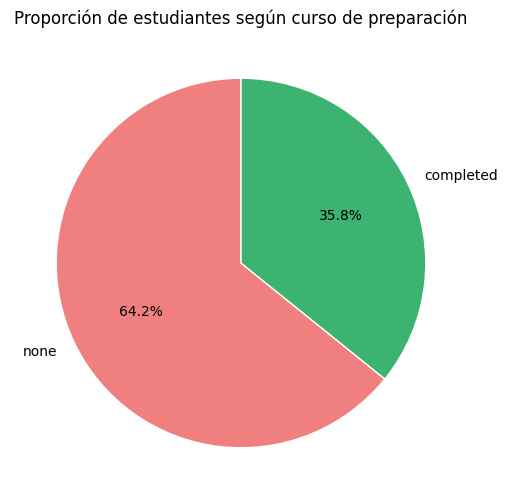

In [32]:
conteo_prep = students_data["test preparation course"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(conteo_prep, labels=conteo_prep.index, autopct="%1.1f%%",
        colors=["lightcoral", "mediumseagreen"], startangle=90,
        wedgeprops={"edgecolor": "white"})
plt.title("Proporción de estudiantes según curso de preparación")
plt.ylabel("")
plt.show()


**Interpretación:** El 64.2% de los estudiantes (642 de 1000) NO completó el curso de preparación, mientras que solo el 35.8% (358) sí lo hizo. Es una proporción notablemente desbalanceada.

**Recomendación:** Dado que completar el curso se asocia con mejores puntajes (visto en Fase 3) y que casi dos tercios de los estudiantes no lo toman, sería recomendable evaluar barreras de acceso (costo, horarios, disponibilidad) y promover su adopción, ya que representa una palanca de mejora accionable, a diferencia de variables demográficas que no se pueden intervenir.

### 18. Histograma: distribución de "math score"

Analizamos la forma de la distribución del puntaje de matemáticas.

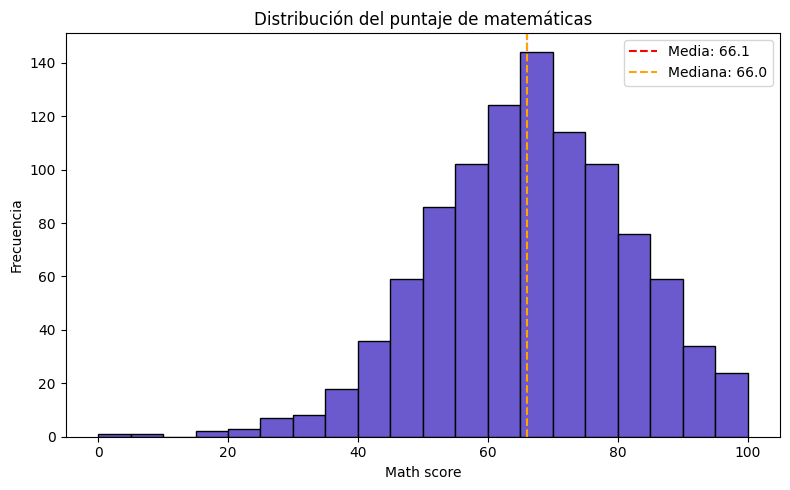

Sesgo (skewness): -0.27893514909431694


In [33]:
plt.figure(figsize=(8,5))
plt.hist(students_data["math score"], bins=20, color="slateblue", edgecolor="black")
plt.axvline(students_data["math score"].mean(), color="red", linestyle="--", label=f'Media: {students_data["math score"].mean():.1f}')
plt.axvline(students_data["math score"].median(), color="orange", linestyle="--", label=f'Mediana: {students_data["math score"].median():.1f}')
plt.title("Distribución del puntaje de matemáticas")
plt.xlabel("Math score")
plt.ylabel("Frecuencia")
plt.legend()
plt.tight_layout()
plt.show()

print("Sesgo (skewness):", students_data["math score"].skew())


**Interpretación:** La distribución es aproximadamente simétrica, con un ligero sesgo hacia la izquierda (skewness ≈ -0.28: cola algo más larga hacia los puntajes bajos). La media (66.1) y la mediana (66.0) son casi idénticas, lo que confirma que no hay una asimetría fuerte. La mayoría de los estudiantes se concentra entre 55 y 80 puntos.

**Recomendación:** Al ser una distribución cercana a la normal, medidas como la media y la desviación estándar son representativas y confiables para fijar metas de desempeño (por ejemplo, considerar "riesgo académico" a quienes estén más de 1 desviación estándar por debajo de la media).

### 19. Scatter plot: relación entre "math score" y "reading score"

Evaluamos si el desempeño en matemáticas se relaciona con el desempeño en lectura.

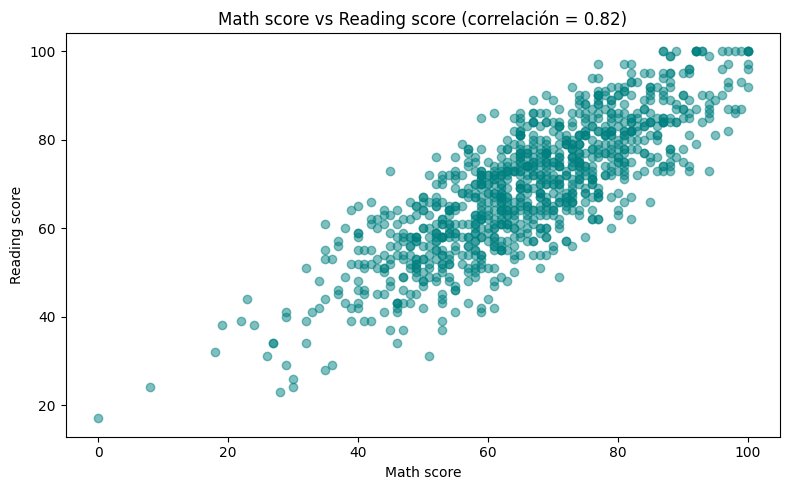

In [34]:
correlacion = students_data["math score"].corr(students_data["reading score"])

plt.figure(figsize=(8,5))
plt.scatter(students_data["math score"], students_data["reading score"], alpha=0.5, color="teal")
plt.title(f"Math score vs Reading score (correlación = {correlacion:.2f})")
plt.xlabel("Math score")
plt.ylabel("Reading score")
plt.tight_layout()
plt.show()


**Interpretación:** Se observa una correlación positiva fuerte (r ≈ 0.82) entre el puntaje de matemáticas y el de lectura: los estudiantes que obtienen buenos resultados en una materia tienden a obtenerlos también en la otra, lo cual sugiere que hay un componente de habilidad académica general (o de hábitos de estudio) que trasciende la materia específica, más que habilidades completamente independientes por asignatura.

**Recomendación:** Como las tres materias están altamente correlacionadas entre sí, para futuros modelos predictivos podría bastar con usar el puntaje total o promedio como variable objetivo en lugar de modelar cada materia por separado, simplificando el análisis sin perder mucha información.

### 20. Boxplot: "math score" por género

Usamos boxplot para visualizar la dispersión y los valores atípicos de matemáticas, y para relacionarlo con lo encontrado en la sección de Valores Atípicos de la Fase 2.

/tmp/ipykernel_561/2266771573.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=students_data, x="gender", y="math score", palette="Set2")


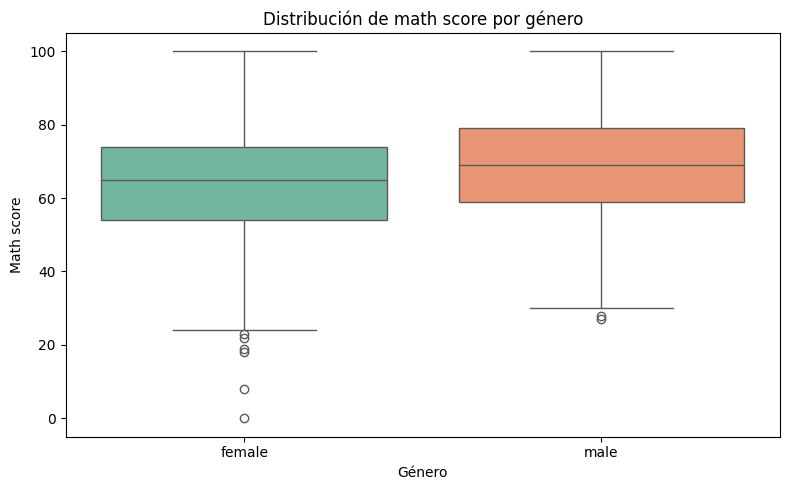

In [35]:
plt.figure(figsize=(8,5))
sns.boxplot(data=students_data, x="gender", y="math score", palette="Set2")
plt.title("Distribución de math score por género")
plt.xlabel("Género")
plt.ylabel("Math score")
plt.tight_layout()
plt.show()


**Interpretación:** El boxplot muestra puntos por fuera de los bigotes en la parte inferior (puntajes muy bajos), lo cual coincide con los 8 outliers que habíamos identificado numéricamente con el criterio de IQR en la Fase 2 (límite inferior ≈ 27 puntos). Además, se ve que la mediana de los hombres es ligeramente superior a la de las mujeres (promedio 68.7 vs 63.6), aunque la dispersión (rango intercuartílico) es similar entre ambos grupos.

**Recomendación:** Los outliers bajos podrían corresponder a estudiantes en riesgo académico real (y no errores de captura, ya que los valores están dentro del rango 0-100), por lo que se recomienda mantenerlos en el análisis pero marcarlos para seguimiento, en vez de eliminarlos.

### 21. Segundo boxplot (no aplica gráfico de líneas): "total_score" por curso de preparación y género

El dataset no tiene ninguna variable temporal (fecha, año o mes), por lo que, según lo indicado en la guía, reemplazamos el gráfico de líneas por un segundo boxplot: comparamos el puntaje total entre 2 o más categorías (curso de preparación y género combinados).

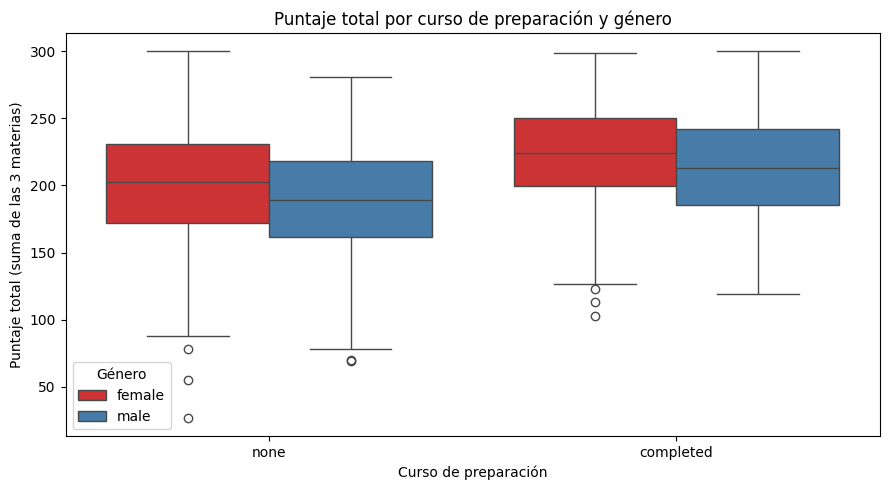

In [36]:
plt.figure(figsize=(9,5))
sns.boxplot(data=students_data, x="test preparation course", y="total_score", hue="gender", palette="Set1")
plt.title("Puntaje total por curso de preparación y género")
plt.xlabel("Curso de preparación")
plt.ylabel("Puntaje total (suma de las 3 materias)")
plt.legend(title="Género")
plt.tight_layout()
plt.show()


**Interpretación:** En ambos géneros, haber completado el curso de preparación desplaza la mediana del puntaje total notablemente hacia arriba, y se nota más consistencia dentro del grupo "completed" (cajas menos dispersas). Las mujeres que completan el curso tienden a alcanzar los puntajes totales más altos del dataset, mientras que los hombres que no lo completan muestran la mayor cantidad de valores atípicos bajos.

**Recomendación:** El curso de preparación parece ser el factor con mayor impacto positivo y accionable sobre el desempeño general, más que el género. Se recomienda priorizar la promoción del curso, especialmente entre hombres, donde se concentran más los casos de bajo desempeño.